In [1]:
# notebook to assess and visualise the single "crystal structure" equilibrium MD simulations
# 
 


In [2]:
import os 
import MDAnalysis as mda
import pandas as pd
from scipy.spatial.distance import pdist
from MDAnalysis.analysis.align import AlignTraj

dragon_dir = "/homes/hussain/hussain-simulation_hdx/projects/xMD"
os.chdir(dragon_dir)

/homes/hussain/hussain-simulation_hdx/programs/miniconda3/envs/p310_MDA/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
BPTI_dir = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test"
BPTI_top = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/clean_top/P00974_60_1_af_sample_127_10000_protonated/P00974_60_1_af_sample_127_10000_protonated_solv_ions.gro"
BPTI_af = "/homes/hussain/hussain-simulation_hdx/projects/xFold_Sampling3/af_sample/BPTI/BPTI/P00974_60_1_af_sample_127_10000_protonated.pdb"

LXR_dir = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test"
LXR_top = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/clean_top/LXRa200_1_af_sample_127_10000_protonated/LXRa200_1_af_sample_127_10000_protonated_solv_ions.gro"
LXR_af = "/homes/hussain/hussain-simulation_hdx/projects/xFold_Sampling3/af_sample/LXRa/LXRa/LXRa200_1_af_sample_127_10000_protonated.pdb"

MBP_dir = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/MBP/MBP_test"
MBP_top = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/clean_top/MBP_wt_1_af_sample_127_10000_protonated/MBP_wt_1_af_sample_127_10000_protonated_solv_ions.gro"
MBP_af = "/homes/hussain/hussain-simulation_hdx/projects/xFold_Sampling3/af_sample/MBP/MBP/MBP_wt_1_af_sample_127_10000_protonated.pdb"
# MBP_af = "/homes/hussain/hussain-simulation_hdx/projects/xMD/clean_top/MBP_wt_1_af_sample_127_10000_protonated/MBP_wt_1_af_sample_127_10000_protonated_solv_ions.gro"

HOIP_dir = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/HOIP/HOIP_test"
HOIP_top = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/clean_top/HOIP_apo697_1_af_sample_127_10000_protonated/HOIP_apo697_1_af_sample_127_10000_protonated_solv_ions.gro"
HOIP_af = "/vols/opig/projects/hussian-simulation_hdx/projects/xFold_Sampling3/af_sample/HOIP/HOIP/HOIP_apo697_1_af_sample_127_10000_protonated.pdb"

BRD4_dir = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/BRD4/BRD4_test"
BRD4_top = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/clean_top/BRD4_APO_484_1_af_sample_127_10000_protonated/BRD4_APO_484_1_af_sample_127_10000_protonated_solv_ions.gro"
BRD4_af  = "/vols/opig/projects/hussian-simulation_hdx/projects/xFold_Sampling3/af_sample/BRD4/BRD4/BRD4_APO_484_1_af_sample_127_10000_protonated.pdb"


n_reps = 5
RMSD_df = pd.DataFrame()
n_reps = 5
# protein = dict(top_paths, traj_paths)
proteins = {"BPTI": {"top": BPTI_top, "dir": BPTI_dir, "af": BPTI_af},
            "LXR": {"top": LXR_top, "dir": LXR_dir , "af": LXR_af},
            "MBP": {"top": MBP_top, "dir": MBP_dir, "af": MBP_af},
            "HOIP": {"top": HOIP_top, "dir": HOIP_dir, "af": HOIP_af},
            "BRD4": {"top": BRD4_top, "dir": BRD4_dir, "af": BRD4_af}}

traj_prefix = "APO_md"



In [4]:
# first we are going to test the already PBC corrected trajectory files 
traj_suffix = "_R"


for protein, d in proteins.items():
    d["traj_files"] = []

    for r in range(1, n_reps+1):
        rep_dir = f"R_{r}"
        rep_dir = os.path.join(d["dir"], rep_dir)
        # find all xtc files in the directory
        traj_files = [f for f in os.listdir(rep_dir) if f.endswith(".xtc")]
        # remove names with # in them 
        traj_files = [f for f in traj_files if "#" not in f]
        # remove names which dont end with a number
        traj_files = [f for f in traj_files if not f.split("_")[-1].split(".")[0].isdigit()]
        # sort the files by the number at the end of the file name
        traj_files = [f for f in traj_files if "mol" not in f]
        traj_files = [f for f in traj_files if traj_suffix not in f]

        # traj_files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
        # add the path to the files
        traj_files = [os.path.join(rep_dir, f) for f in traj_files]

        print(traj_files)
        d["traj_files"].append([traj_files])




    

['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/APO_md_P00974_60_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/APO_md_P00974_60_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/APO_md_P00974_60_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_4/APO_md_P00974_60_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_5/APO_md_P00974_60_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_1/APO_md_LXRa_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_2/APO_md_LXRa_12-nojump.xtc', '/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_2/APO_md_LXRa_6-nojump.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_3/APO_md_LXRa_12

In [5]:
import os
import subprocess
from multiprocessing import Pool

def process_replicate(args):
    protein, d, r = args
    rep_dir = f"R_{r}"
    rep_dir = os.path.join(d["dir"], rep_dir)

    # find all xtc files in the directory
    traj_files = [f for f in os.listdir(rep_dir) if f.endswith(".xtc")]
    # remove names with # in them
    traj_files = [f for f in traj_files if "#" not in f]
    # remove names which dont end with a number
    traj_files = [f for f in traj_files if f.split("_")[-1].split(".")[0].isdigit()]
    # sort the files by the number at the end of the file name
    traj_files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
    # add the path to the files
    traj_files = [os.path.join(rep_dir, f) for f in traj_files]

    tpr_files = [traj.replace(".xtc", ".tpr") for traj in traj_files]

    # concatenate trajectory files using Gromacs trjcat command
    concatenated_traj = os.path.join(rep_dir, f"{protein}_R{r}_concatenated.xtc")
    command = ["gmx", "trjcat", "-f"] + traj_files + ["-o", concatenated_traj] + ["-cat"]
    subprocess.run(command, check=True)

    # select the first tpr file as the concatenated tpr file
    concatenated_tpr = tpr_files[0]

    # perform mol center and pbc nojump using trjconv

    centered_traj = os.path.join(rep_dir, f"{protein}_R{r}_centered.xtc")
    nojump_traj = os.path.join(rep_dir, f"{protein}_R{r}_nojump.xtc")
    traj_top = nojump_traj.replace(".xtc", ".pdb")


    command = ["gmx", "trjconv", "-f", concatenated_traj, "-s", concatenated_tpr, "-o", centered_traj, "-pbc", "mol", "-center"]
    subprocess.run(command, input=b"1\n1\n", check=True)
    
    # write only the first frame to a pdb file
    command = ["gmx", "editconf", "-f", concatenated_tpr, "-o", traj_top,  "-ndef"]
    subprocess.run(command, input=b"1\n", check=True)

    command = ["gmx", "trjconv", "-f", centered_traj, "-s", traj_top, "-o", nojump_traj, "-pbc", "nojump"]
    subprocess.run(command, input=b"1\n", check=True)



    # u = mda.Universe(traj_top)

    # print(len(u.trajectory))


    # remove the concatenated trajectory using rm command
    os.remove(concatenated_traj)
    os.remove(centered_traj)

    return nojump_traj, concatenated_tpr

# todo = ["HOIP", "BRD4"]
# first we are going to test the already PBC corrected trajectory files

for protein, d in proteins.items():
    d["nojump_traj"] = []
    d["concatenated_tpr"] = []
    break
    with Pool() as pool:
        args = [(protein, d, r) for r in range(1, n_reps+1)]
        results = pool.map(process_replicate, args)

        for nojump_traj, concatenated_tpr in results:
            d["nojump_traj"].append(nojump_traj)
            d["concatenated_tpr"].append(concatenated_tpr)

In [6]:
top = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/BRD4/BRD4_test/R_3/BRD4_APO_484_1_af_sample_127_10000_protonated_em.gro"

traj = "/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/BRD4/BRD4_test/R_3/BRD4_R3_nojump.xtc"

u = mda.Universe(top, traj)#, topology_format="GROMOS", trajectory_format="xtc")

OSError: File does not exist: b'/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/BRD4/BRD4_test/R_3/BRD4_R3_nojump.xtc'

ImportError: cannot import name 'TPRParser' from 'MDAnalysis.topology.tpr' (/homes/hussain/hussain-simulation_hdx/programs/miniconda3/envs/p310_MDA/lib/python3.10/site-packages/MDAnalysis/topology/tpr/__init__.py)

In [ ]:
import os
import subprocess
from multiprocessing import Pool
import MDAnalysis as mda
from MDAnalysis import lib

def process_replicate(args):
    print(args)
    protein, d, r = args
    rep_dir = f"R_{r}"
    rep_dir = os.path.join(d["dir"], rep_dir)
    
    # find all xtc files in the directory
    traj_files = [f for f in os.listdir(rep_dir) if f.endswith(".xtc")]
    
    # remove names with # in them
    traj_files = [f for f in traj_files if "#" not in f]
    
    # remove names which dont end with a number
    traj_files = [f for f in traj_files if f.split("_")[-1].split(".")[0].isdigit()]
    
    # sort the files by the number at the end of the file name
    traj_files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
    
    # add the path to the files
    traj_files = [os.path.join(rep_dir, f) for f in traj_files]
    tpr_files = [traj.replace(".xtc", ".tpr") for traj in traj_files]
    
    # concatenate trajectory files using Gromacs trjcat command
    concatenated_traj = os.path.join(rep_dir, f"{protein}_R{r}_concatenated.xtc")
    # command = ["gmx", "trjcat", "-f"] + traj_files + ["-o", concatenated_traj] + ["-cat"]
    # subprocess.run(command, check=True)
    
    # select the first tpr file as the concatenated tpr file
    concatenated_tpr = tpr_files[0]
    
    centered_traj = os.path.join(rep_dir, f"{protein}_R{r}_centered.xtc")
    nojump_traj = os.path.join(rep_dir, f"{protein}_R{r}_nojump.xtc")
    traj_top = nojump_traj.replace(".xtc", ".pdb")

    # load the concatenated trajectory and tpr file into MDAnalysis

    u.select_atoms("protein")

    # load the trajectory into MDAnalysis
    # u.load_new(concatenated_traj)

    # select the protein atoms
    # protein_atoms = u.select_atoms("protein")
    
    # # correct PBC for the protein
    # protein_atoms.wrap("fragments")

    # # save the PBC corrected trajectory
    # pbc_corrected_traj = os.path.join(rep_dir, f"{protein}_R{r}_pbc_corrected.xtc")
    # with mda.Writer(pbc_corrected_traj, protein_atoms.n_atoms) as W:
    #     for ts in u.trajectory:
    #         W.write(protein_atoms)
    
    return pbc_corrected_traj, concatenated_tpr

# todo = ["HOIP", "BRD4"]

# first we are going to test the already PBC corrected trajectory files
for protein, d in proteins.items():
    d["pbc_corrected_traj"] = []
    d["concatenated_tpr"] = []
    break
    with Pool() as pool:
        args = [(protein, d, r) for r in range(1, n_reps+1)]
        results = pool.map(process_replicate, args)
        
        for pbc_corrected_traj, concatenated_tpr in results:
            d["pbc_corrected_traj"].append(pbc_corrected_traj)
            d["concatenated_tpr"].append(concatenated_tpr)

('BPTI', {'top': '/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/clean_top/P00974_60_1_af_sample_127_10000_protonated/P00974_60_1_af_sample_127_10000_protonated_solv_ions.gro', 'dir': '/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test', 'af': '/homes/hussain/hussain-simulation_hdx/projects/xFold_Sampling3/af_sample/BPTI/BPTI/P00974_60_1_af_sample_127_10000_protonated.pdb', 'traj_files': [[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/APO_md_P00974_60_6-nojump.xtc']], [['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/APO_md_P00974_60_6-nojump.xtc']], [['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/APO_md_P00974_60_6-nojump.xtc']], [['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_4/APO_md_P00974_60_6-nojump.xtc']], [['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_5/AP

ValueError: 'TPR' isn't a valid topology format, nor a coordinate format
   from which a topology can be minimally inferred.
   You can use 'Universe(topology, ..., topology_format=FORMAT)'
   to explicitly specify the format and
   override automatic detection. Known FORMATs are:
   dict_keys([])
   See https://docs.mdanalysis.org/documentation_pages/topology/init.html#supported-topology-formats
   For missing formats, raise an issue at 
   https://github.com/MDAnalysis/mdanalysis/issues

In [ ]:
# import os
# from MDAnalysis import Universe, Writer
# todo = ["HOIP", "BRD4"]
# # first we are going to test the already PBC corrected trajectory files
# for protein, d in proteins.items():
#     if protein not in todo:
#         continue

#     d["concatenated_traj"] = []
#     d["concatenated_tpr"] = []
    
#     for r in range(1, n_reps+1):
#         print(protein, r)
#         rep_dir = f"R_{r}"
#         rep_dir = os.path.join(d["dir"], rep_dir)
#         print(rep_dir)
#         # find all xtc files in the directory
#         traj_files = [f for f in os.listdir(rep_dir) if f.endswith(".xtc")]
        
#         # remove names with # in them
#         traj_files = [f for f in traj_files if "#" not in f]
        
#         # remove names which dont end with a number
#         traj_files = [f for f in traj_files if f.split("_")[-1].split(".")[0].isdigit()]
        
#         # sort the files by the number at the end of the file name
#         traj_files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
        
#         # add the path to the files
#         traj_files = [os.path.join(rep_dir, f) for f in traj_files]
#         top_files = [traj.replace(".xtc", ".gro") for traj in traj_files]
        

#         u = Universe(top_files[0], traj_files)

#         # concatenate trajectory files using MDAnalysis
#         concatenated_traj = os.path.join(rep_dir, f"{protein}_R{r}_concatenated.xtc")
#         # with Writer(concatenated_traj, u.trajectory.n_atoms) as writer:
#         #     for idx,traj in enumerate(traj_files):
#         #         print(idx, end="\r")
#         #         u = Universe(top_files[0], traj)
#         #         for ts in u.trajectory:
#         #             print(ts, end="\r")
#         #             writer.write(u)



#         #
#         # correct PBC using MDAnalysis
#         u = Universe(top_files[0], concatenated_traj)
#         u.atoms.wrap(compound='fragments')
#         u.atoms.center_in_box()
        
#         # write the PBC corrected trajectory
#         pbc_corrected_traj = os.path.join(rep_dir, f"{protein}_R{r}_pbc_corrected.xtc")
#         # with Writer(pbc_corrected_traj, u.trajectory.n_atoms) as writer:
#         #     for ts in u.trajectory:
#         #         print(ts, end="\r")
#         #         writer.write(u)
        
#         d["concatenated_traj"].append(concatenated_traj)
#         d["concatenated_tpr"].append(tpr_files[0])

HOIP 1
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/HOIP/HOIP_test/R_1


KeyboardInterrupt: 

In [7]:
# first we are going to test the already PBC corrected trajectory files 

traj_suffix = "_nojump_relax+prod"

for protein, d in proteins.items():
    d["traj_files"] = []

    for r in range(1, n_reps+1):
        rep_dir = f"R_{r}"
        rep_dir = os.path.join(d["dir"], rep_dir)
        # find all xtc files in the directory
        traj_files = [f for f in os.listdir(rep_dir) if f.endswith(".xtc")]
        # remove names with # in them 
        traj_files = [f for f in traj_files if "#" not in f]
        # remove names which dont end with a number
        # traj_files = [f for f in traj_files if not f.split("_")[-1].split(".")[0].isdigit()]
        # sort the files by the number at the end of the file name
        traj_files = [f for f in traj_files if traj_suffix in f]

        # traj_files.sort(key=lambda x: int(x.split("_")[-1].split(".")[0]))
        # add the path to the files~~
        traj_files = [os.path.join(rep_dir, f) for f in traj_files]

        print(traj_files)
        d["traj_files"].append([traj_files])




    

['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/BPTI_R1_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/BPTI_R2_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/BPTI_R3_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_4/BPTI_R4_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_5/BPTI_R5_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_1/LXR_R1_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_2/LXR_R2_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_3/LXR_R3_nojump_relax+prod.xtc']
['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/LXRa/LXRa_test/R_4/LX

In [8]:
traj_lengths = {}

for protein,d  in proteins.items():

    traj_lengths[protein] = []

    for r in range(n_reps):
        traj_files = d["traj_files"][r]
        print(traj_files)
        top = traj_files[0][0].replace("xtc", "pdb")
        print(top)
        traj = mda.Universe(top, traj_files)
        # print len of each trajectory
        print(f"Trajectory length for {protein} rep {r+1}: {len(traj.trajectory)}")
        traj_lengths[protein].append(len(traj.trajectory))

[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/BPTI_R1_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/BPTI_R1_nojump_relax+prod.pdb
Trajectory length for BPTI rep 1: 3002
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/BPTI_R2_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/BPTI_R2_nojump_relax+prod.pdb
Trajectory length for BPTI rep 2: 3002
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/BPTI_R3_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/BPTI_R3_nojump_relax+prod.pdb
Trajectory length for BPTI rep 3: 3002
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_4/BPTI_R4_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60

In [9]:
universes = {}

for protein, d in proteins.items():
    universes[protein] = []
    for r in range(n_reps):
        traj_files = d["traj_files"][r]
        print(traj_files)
        top = traj_files[0][0].replace("xtc", "pdb")
        print(top)
        traj = mda.Universe(top, traj_files)     
        universes[protein].append([traj])

[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/BPTI_R1_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_1/BPTI_R1_nojump_relax+prod.pdb
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/BPTI_R2_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_2/BPTI_R2_nojump_relax+prod.pdb
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/BPTI_R3_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_3/BPTI_R3_nojump_relax+prod.pdb
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_4/BPTI_R4_nojump_relax+prod.xtc']]
/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/BPTI_test/R_4/BPTI_R4_nojump_relax+prod.pdb
[['/homes/hussain/hussain-simulation_hdx/projects/xMD/data/MD/P00974_60/

In [10]:
# from MDAnalysis.analysis import rms
# import pandas as pd
# import numpy as np

# RMSF_df = pd.DataFrame()

# for protein, d in proteins.items():
#     for r in range(n_reps):
#         traj = universes[protein][r][0]
#         ref = mda.Universe(d["af"])
#         # Align the trajectory to the reference structure
#         # alignment = mda.analysis.align.AlignTraj(traj,ref,select="protein and name CA", in_memory=True).run()
        
#         # Calculate RMSF
#         RMSF = mda.analysis.rms.RMSF(traj, select="protein and name CA")
#         RMSF.run()
        
#         rmsf_values = RMSF.results.rmsf
#         residue_indices = RMSF.results.atom_indices
        
#         # Create a DataFrame with RMSF values, residue indices, replica, and protein name
#         df_to_add = pd.DataFrame({
#             "RMSF": rmsf_values,
#             "Residue": residue_indices,
#             "Rep": [r+1]*len(rmsf_values),
#             "Protein": [protein]*len(rmsf_values)
#         })
        
#         RMSF_df = pd.concat([RMSF_df, df_to_add])

In [11]:
# # calc RMSD for each traj from the first frame
# from MDAnalysis.analysis import rms
# import pandas as pd
# import numpy as np

# # RMSD_df = pd.DataFrame()

# for protein, d in proteins.items():
#     ref = d["af"]
#     ref = mda.Universe(ref)
#     for r in range(n_reps):
#         traj = universes[protein][r][0]
#         RMSD = mda.analysis.rms.RMSD(traj, ref, select="protein and name CA")
#         RMSD.run()
#         print(RMSD.results.rmsd)
#         rmsd = RMSD.results.rmsd[:, 2]
#         # add RMSD, frames and rep columns to the dataframe with protein name
#         df_to_add = pd.DataFrame({"af_RMSD": rmsd, "Frames": range(len(rmsd)), "Rep": [r+1]*len(rmsd), "Protein": [protein]*len(rmsd)})
#         RMSD_df = pd.concat([RMSD_df, df_to_add])


In [12]:
from sklearn.decomposition import PCA


In [13]:
import pandas as pd
import numpy as np


## change this so that we can calculate PCA for residues specified by HDX-MS data
def calculate_pca(universes, num_components=2, residues:list=None, ref_frame_index:int=0):
    sel = "protein and name CA"
    if residues is not None:
        resi_sel = " or ".join([f" resid {res}" for res in residues])
        sel = sel + f" and ({resi_sel})"

    n_reps = len(universes)
    n_frames_per_rep = len(universes[0].trajectory)
    n_frames_total = n_reps * n_frames_per_rep
    n_residues = len(universes[0].select_atoms(sel))

    calc_intra_residue_dist = np.zeros((n_frames_total, n_residues*(n_residues-1)//2))

    for r, universe in enumerate(universes):

        universe.trajectory[ref_frame_index]
        ref = universe.select_atoms(sel)
        # alignment = mda.analysis.align.AlignTraj(universe, ref, select=sel, in_memory=True).run()

        for i, ts in enumerate(universe.trajectory):
            print(r,i, end="\r")
            coords = ref.positions
            calc_intra_residue_dist[r*n_frames_per_rep + i] = pdist(coords)

    pca = PCA(n_components=num_components)
    pca.fit(calc_intra_residue_dist)
    data = pca.transform(calc_intra_residue_dist)

    return data

pca_df = pd.DataFrame()
n_dims = 2

for protein, d in proteins.items():
    print(protein)
    pca_data = calculate_pca([universes[protein][r][0] for r in range(n_reps)], num_components=n_dims, ref_frame_index=0)

    frames = np.repeat(range(len(pca_data) // n_reps), n_reps)
    reps = np.tile(range(1, n_reps+1), len(pca_data) // n_reps)

    df_to_add = pd.DataFrame({
        "PC1": pca_data[:, 0],
        "PC2": pca_data[:, 1],
        "Frames": frames,
        "Rep": reps,
        "Protein": [protein]*len(pca_data)
    })

    pca_df = pd.concat([pca_df, df_to_add])

BPTI
LXR001
MBP001
HOIP01
BRD401


<Figure size 2000x1000 with 0 Axes>

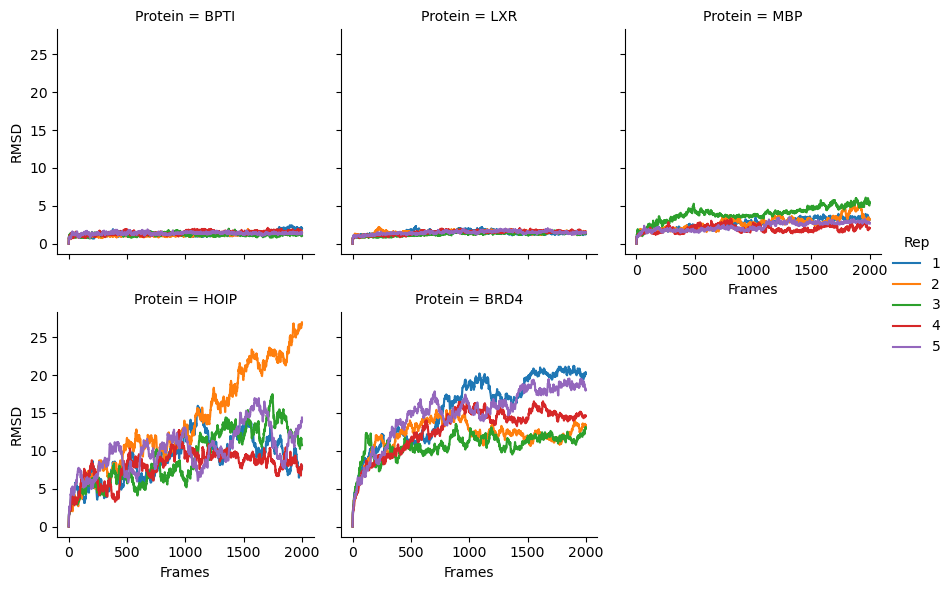

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# # facet grid of RMSD against frames for each protein
# plt.figure(figsize=(20, 10))
# g = sns.FacetGrid(RMSD_df, col="Protein", hue="Rep", col_wrap=3)

# g.map(sns.lineplot, "Frames", "RMSD")

# g.add_legend()
# # plt.yscale("log")
# # plt.ylim(0.5,6)
# plt.show()
# plt.close()

In [14]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create a subplot grid
num_proteins = len(pca_df['Protein'].unique())
num_cols = 3
num_rows = (num_proteins - 1) // num_cols + 1

fig = make_subplots(rows=num_rows, cols=num_cols, subplot_titles=pca_df['Protein'].unique())

# Iterate over each protein and add traces to the subplots
for i, protein in enumerate(pca_df['Protein'].unique()):
    protein_df = pca_df[pca_df['Protein'] == protein]
    
    row = i // num_cols + 1
    col = i % num_cols + 1
    
    # Iterate over each unique Rep value and add traces with different colors
    for rep in protein_df['Rep'].unique():
        rep_df = protein_df[protein_df['Rep'] == rep]
        fig.add_trace(go.Scatter(x=rep_df['PC1'], y=rep_df['PC2'], mode='markers', name=f"{protein} - Rep {rep}",
                                 marker=dict(size=6,opacity=0.5)),
                      row=row, col=col)

# Update layout
fig.update_layout(title='PCA Scatter Plot for Each Protein (Colored by Rep)',
                  xaxis_title='PC1',
                  yaxis_title='PC2',
                  height=num_rows * 400,
                  width=num_cols * 400,
                  showlegend=True)

# Show the plot
fig.show()